# **Question 4.4.1**
**Can this polynomial regression problem be solved accurately?**

$$
\begin{aligned}
L(w) &= \frac{1}{2}\sum\limits_{i=1}^{N}\left(\sum\limits_{j=0}^{M} w_{j}x^{j}_{i}-y_{j} \right)^{2} \\
\frac{\partial{L(w)}}{\partial{w_k}} &= 0 \Rightarrow \frac{1}{2}\sum\limits_{i=1}^{N}2\left(\sum\limits_{j=0}^{M} w_{j}x^{j}_{i}-y_{j} \right) \times x_{i}^{k} = 0 \Rightarrow \sum\limits_{i=1}^{N} \sum\limits_{j=0}^{M} w_{j}x^{j+k}_{i} = \sum\limits_{i=1}^{N}x_{i}^{k}y_{i}(k=0,1,2...,M) \Rightarrow XW = Y \\
\end{aligned}
$$
$$
X=
\begin{bmatrix}
N & \sum_{i=1}^{N}x_{i} & \sum_{i=1}^{N}x_{i}^{2} & \cdots & \sum_{i=1}^{N}x_{i}^{M} \\
\sum_{i=1}^{M}x_{i} & \sum_{i=1}^{M}x_{i}^{2} & \sum_{i=1}^{M}x_{i}^{3} & \cdots & \sum_{i=1}^{M}x_{i}^{N+1} \\
\sum_{i=1}^{M}x_{i}^{2} & \sum_{i=1}^{M}x_{i}^{3} & \sum_{i=1}^{M}x_{i}^{4} & \cdots & \sum_{i=1}^{M}x_{i}^{N+2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\sum_{i=1}^{M}x_{i}^{N} & \sum_{i=1}^{M}x_{i}^{N+1} & \sum_{i=1}^{M}x_{i}^{N+2} & \cdots & \sum_{i=1}^{M}x_{i}^{2N} \\
\end{bmatrix},
W=
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
\vdots \\
w_M \\
\end{bmatrix},
Y=
\begin{bmatrix}
\sum_{i=1}^{N}y_{i} \\
\sum_{i=1}^{N}(x_{i}y_{i}) \\
\sum_{i=1}^{N}(x_{i}^{2}y_{i}) \\
\vdots \\
\sum_{i=1}^{N}(x_{i}^{N}y_{i}) \\
\end{bmatrix}
$$
$$
\begin{aligned}
W = X^{-1}Y
\end{aligned}
$$

# **Question 4.4.2**
**Model selection for polynomial models.**

**1.Plot the relationship between training loss and model complexity (polynomial degree). What do you observe? What degree of polynomial is required to reduce the training loss to 0?**<br>
1.Before the polynomial degree reaches 4, increasing the degree reduces the training loss; when the degree exceeds 4, the training loss remains nearly constant at around 0.01.

**2.Plot the loss curve for the test under these conditions.**

([47.89793869018555,
  18.83513641357422,
  5.636022033691407,
  0.008127021491527558,
  0.012301287651062011,
  0.018972641378641127,
  0.01679247763007879,
  0.016535925939679147,
  0.018034160435199738,
  0.018581904247403146,
  0.017675383612513543,
  0.01787000983953476,
  0.017475922405719758,
  0.016977920308709146,
  0.01814614623785019,
  0.0163702055811882,
  0.015610225200653076,
  0.01669536404311657,
  0.017427457347512245,
  0.015309655368328094],
 [108.79681602478027,
  59.54548892974854,
  18.273901319503786,
  0.009555987268686294,
  0.04697311125695705,
  0.3870083163678646,
  0.2951400215923786,
  0.24274184167385102,
  0.35130360946059225,
  0.3883888817578554,
  0.315339587405324,
  0.3244240123778582,
  0.3515695377439261,
  0.2859245777130127,
  0.3609510526061058,
  0.30915596917271615,
  0.23837833926081659,
  0.3089259045571089,
  0.2645513416826725,
  0.2241725518554449])

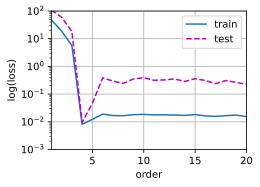

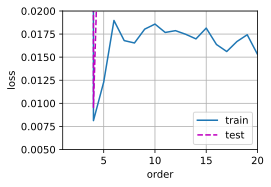

In [2]:
import math
import torch
from d2l import torch as d2l
from torch import nn
import numpy as np

n_train, n_test = 100, 100  # Size of the training and test datasets

def train4_4_2(order_list, n_train, n_test, num_epochs=400, show=True):
    max_degree = 20 # Maximum Degree of a Polynomial
    true_w = np.zeros(max_degree)
    true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

    features = np.random.normal(size=(n_train + n_test, 1))
    np.random.shuffle(features)
    poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
    for i in range(max_degree):
        poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
    # labels的维度:(n_train+n_test,)
    labels = np.dot(poly_features, true_w)
    labels += np.random.normal(scale=0.1, size=labels.shape)
    true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]
    if show==True:
        animator = d2l.Animator(xlabel='order', ylabel='log(loss)', yscale='log',
                                xlim=[1, order_list[-1]], ylim=[1e-3, 1e2],
                                legend=['train', 'test'])
        animator2 = d2l.Animator(xlabel='order', ylabel='loss',
                                 xlim=[1, order_list[-1]], ylim=[0.005, 0.02], legend=['train', 'test'])
    train_losslist,test_losslist=[],[]

    for i in order_list:
        train_features, test_features, train_labels, test_labels=poly_features[:n_train, :i],poly_features[n_test:, :i],labels[:n_train], labels[n_test:]
        loss = nn.MSELoss(reduction='none')
        input_shape = train_features.shape[-1]
        net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
        batch_size = min(10, train_labels.shape[0])
        train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),batch_size)
        test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
        trainer = torch.optim.SGD(net.parameters(), lr=0.01)
        for epoch in range(num_epochs):
            d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        train_loss=d2l.evaluate_loss(net, train_iter, loss)
        test_loss=d2l.evaluate_loss(net, test_iter, loss)
        train_losslist.append(train_loss)
        test_losslist.append(test_loss)
        if show==True:
            animator.add(i, (train_loss,test_loss))
            animator2.add(i, (train_loss,test_loss))
    return train_losslist,test_losslist
    #print('weight:', net[0].weight.data.numpy())
    #return d2l.evaluate_loss(net, train_iter, loss),d2l.evaluate_loss(net, test_iter, loss)

train4_4_2(np.arange(1,21),n_train, n_test,400)

**Generate the same graph as a function of the data volume.**

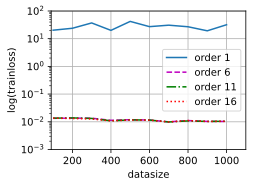

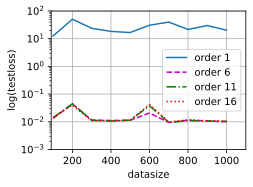

In [3]:
animator = d2l.Animator(xlabel='datasize', ylabel='log(trainloss)', yscale='log',
                                xlim=[90, 1100], ylim=[1e-3, 1e2],
                                legend=list(map(lambda x: "order {}".format(x),np.arange(1,21,5))))
animator2 = d2l.Animator(xlabel='datasize', ylabel='log(testloss)', yscale='log',
                                xlim=[90, 1100], ylim=[1e-3, 1e2],
                                legend=list(map(lambda x: "order {}".format(x),np.arange(1,21,5))))
for datasize in range(100,1100,100):
    train_losslist,test_losslist=train4_4_2(np.arange(1,21,5),datasize, datasize,num_epochs=400,show=False)
    animator.add(datasize, list(train_losslist))
    animator2.add(datasize, list(test_losslist))


# **Question 4.4.3**
**What happens if the polynomial eigenvalues $x^{i}$ are not normalized $(1/i^{!})$? Are there other ways to solve this problem?**<br><br>
Avoid large gradient or loss values. In addition to this approach, we can also subtract the mean of the feature’s data from each feature and divide it by the standard deviation.

# **Question 4.4.4**
**Can the generalization error be zero?**<br><br>
When there is sufficient training data, the generalization error approaches the empirical error; experiments have shown that for solvable problems with noise-free data, the generalization error can be zero.